# Deteksi Anomali pada Indikator Ekonomi Makro
## *Early Warning System* menggunakan Data Mining

| Item | Detail |
|---|---|
| **Topik** | Anomaly Detection pada Indikator Ekonomi Multi-Negara |
| **Sumber Data** | World Bank Open Data API (`wbgapi`) |
| **Algoritma** | Isolation Forest, Local Outlier Factor (LOF), Autoencoder |
| **Reduksi Dimensi** | PCA, t-SNE |
| **Evaluasi** | Precision, Recall, F1-Score, SHAP Feature Importance |

In [72]:
# Install library yang dibutuhkan (jalankan sekali)
!pip install wbgapi pandas numpy matplotlib seaborn scikit-learn tensorflow shap -q

In [73]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
try:
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_TF = True
    print("TensorFlow berhasil diimport")
except ImportError:
    HAS_TF = False
    print("TensorFlow tidak tersedia - Autoencoder akan di-skip")

# SHAP
try:
    import shap
    HAS_SHAP = True
    print("SHAP berhasil diimport")
except ImportError:
    HAS_SHAP = False
    print("SHAP tidak tersedia - Feature importance akan gunakan metode alternatif")

# Plot style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')

sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("\nSemua library berhasil diimport!")

TensorFlow berhasil diimport
SHAP berhasil diimport

Semua library berhasil diimport!


---
## 1. Data Acquisition (Ekstraksi Data)

Mengambil data indikator ekonomi makro dari **World Bank API** menggunakan library `wbgapi`.

- **15 indikator ekonomi** yang sensitif terhadap krisis
- **48 negara** dari berbagai kawasan (G7, BRICS, ASEAN, dll.)
- **Periode: 1990-2024** (35 tahun)

In [74]:
# ============================================================
# Definisi 15 Indikator Ekonomi Makro (Revisi Final)
# Menggunakan komponen National Accounts agar missing value minimal
# ============================================================
indicators = {
    # --- 11 Indikator Asli yang Aman ---
    'NY.GDP.MKTP.KD.ZG': 'GDP_Growth',
    'NY.GDP.PCAP.KD.ZG': 'GDP_PerCapita_Growth',
    'FP.CPI.TOTL.ZG': 'Inflation_CPI',
    'FI.RES.TOTL.CD': 'Total_Reserves',
    'SL.UEM.TOTL.ZS': 'Unemployment',
    'BN.CAB.XOKA.GD.ZS': 'Current_Account_GDP',
    'NE.TRD.GNFS.ZS': 'Trade_GDP',
    'BX.KLT.DINV.WD.GD.ZS': 'FDI_Inflows_GDP',
    'NE.EXP.GNFS.ZS': 'Exports_GDP',
    'NE.IMP.GNFS.ZS': 'Imports_GDP',
    'NY.GNS.ICTR.ZS': 'Gross_Savings_GDP',
    'PA.NUS.FCRF': 'Exchange_Rate',
    'NV.IND.MANF.ZS': 'Manufacturing_Value',
    'NE.GDI.TOTL.ZS': 'Investment_GDP',       # Pengganti Lending Rate
}

# ============================================================
# 48 Negara dari Berbagai Kawasan
# ============================================================
countries = [
    # G7
    'USA', 'GBR', 'DEU', 'FRA', 'ITA', 'JPN', 'CAN',
    # BRICS
    'BRA', 'RUS', 'IND', 'CHN', 'ZAF',
    # ASEAN
    'IDN', 'THA', 'MYS', 'PHL', 'VNM', 'SGP',
    # Other Asia
    'KOR', 'PAK', 'BGD', 'LKA',
    # Latin America
    'MEX', 'ARG', 'COL', 'CHL', 'PER',
    # Middle East & Africa
    'SAU', 'TUR', 'EGY', 'NGA', 'KEN', 'ARE',
    # Europe
    'ESP', 'NLD', 'SWE', 'NOR', 'POL', 'GRC', 'PRT',
    'IRL', 'CHE', 'AUT', 'BEL', 'CZE', 'HUN', 'ROU',
    # Oceania
    'AUS', 'NZL'
]

years = range(1990, 2025)

print(f"Jumlah Indikator : {len(indicators)}")
print(f"Jumlah Negara    : {len(countries)}")
print(f"Periode          : {min(years)}-{max(years)} ({len(list(years))} tahun)")
print(f"Estimasi Max Rows: {len(countries)} x {len(list(years))} = {len(countries) * len(list(years)):,}")

Jumlah Indikator : 14
Jumlah Negara    : 49
Periode          : 1990-2024 (35 tahun)
Estimasi Max Rows: 49 x 35 = 1,715


In [75]:
# ============================================================
# Mengambil Data dari World Bank API
# ============================================================
print("Mengambil data dari World Bank API...")
print("=" * 60)

all_data = []

for i, (ind_code, ind_name) in enumerate(indicators.items(), 1):
    try:
        print(f"  [{i:2d}/{len(indicators)}] {ind_name:.<35s}", end=" ")
        df_temp = wb.data.DataFrame(
            ind_code,
            economy=countries,
            time=years,
            numericTimeKeys=True
        )

        # Reshape: wide -> long format
        df_temp = df_temp.reset_index()
        id_col = df_temp.columns[0]
        df_temp = df_temp.melt(id_vars=[id_col], var_name='year', value_name=ind_name)
        df_temp = df_temp.rename(columns={id_col: 'economy'})
        df_temp['year'] = df_temp['year'].astype(int)

        non_null = df_temp[ind_name].notna().sum()
        all_data.append(df_temp)
        print(f"OK ({non_null:,} values)")
    except Exception as e:
        print(f"GAGAL: {e}")

# Merge semua indikator
print("\nMenggabungkan semua indikator...")
df = all_data[0]
for d in all_data[1:]:
    df = df.merge(d, on=['economy', 'year'], how='outer')

df = df.sort_values(['economy', 'year']).reset_index(drop=True)

print(f"\n{'=' * 60}")
print(f"Dataset berhasil dibuat!")
print(f"   Shape       : {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"   Negara unik : {df['economy'].nunique()}")
print(f"   Tahun       : {df['year'].min()} - {df['year'].max()}")

Mengambil data dari World Bank API...
  [ 1/14] GDP_Growth......................... OK (1,712 values)
  [ 2/14] GDP_PerCapita_Growth............... OK (1,712 values)
  [ 3/14] Inflation_CPI...................... OK (1,657 values)
  [ 4/14] Total_Reserves..................... OK (1,704 values)
  [ 5/14] Unemployment....................... OK (1,666 values)
  [ 6/14] Current_Account_GDP................ OK (1,610 values)
  [ 7/14] Trade_GDP.......................... OK (1,657 values)
  [ 8/14] FDI_Inflows_GDP.................... OK (1,710 values)
  [ 9/14] Exports_GDP........................ OK (1,657 values)
  [10/14] Imports_GDP........................ OK (1,657 values)
  [11/14] Gross_Savings_GDP.................. OK (1,563 values)
  [12/14] Exchange_Rate...................... OK (1,706 values)
  [13/14] Manufacturing_Value................ OK (1,596 values)
  [14/14] Investment_GDP..................... OK (1,652 values)

Menggabungkan semua indikator...

Dataset berhasil dibuat!
   Sha

In [76]:
# Simpan ke CSV sebagai backup
df.to_csv('economic_indicators_raw_final.csv', index=False)
print("Data disimpan ke 'economic_indicators_raw.csv'")
print(f"\nPreview data:")
df.head(15)

Data disimpan ke 'economic_indicators_raw.csv'

Preview data:


,economy,year,GDP_Growth,GDP_PerCapita_Growth,Inflation_CPI,Total_Reserves,Unemployment,Current_Account_GDP,Trade_GDP,FDI_Inflows_GDP,Exports_GDP,Imports_GDP,Gross_Savings_GDP,Exchange_Rate,Manufacturing_Value,Investment_GDP
0,ARE,1990,18.327986,11.572665,NaN,4.890565e+09,NaN,NaN,NaN,-0.228435,NaN,NaN,NaN,3.671000,7.493889,NaN
1,ARE,1991,0.860082,-4.588785,NaN,5.646814e+09,1.629,NaN,NaN,0.050318,NaN,NaN,NaN,3.671000,7.423064,NaN
2,ARE,1992,3.344945,-1.938000,NaN,5.977161e+09,1.715,NaN,NaN,0.239163,NaN,NaN,NaN,3.671000,7.583672,NaN
3,ARE,1993,1.261191,-3.631361,NaN,6.415332e+09,1.901,NaN,NaN,0.721472,NaN,NaN,NaN,3.671000,7.843781,NaN
4,ARE,1994,6.896149,2.024915,NaN,6.963510e+09,1.834,NaN,NaN,0.105320,NaN,NaN,NaN,3.671000,6.587693,NaN
5,ARE,1995,6.687886,2.022152,NaN,7.778376e+09,1.800,NaN,NaN,0.608195,NaN,NaN,NaN,3.671000,6.772463,NaN
6,ARE,1996,5.798404,-0.836571,NaN,8.350159e+09,1.836,NaN,NaN,0.408475,NaN,NaN,NaN,3.671000,6.637293,NaN
7,ARE,1997,8.190399,-0.251832,NaN,8.603051e+09,1.906,NaN,NaN,0.294816,NaN,NaN,NaN,3.671125,7.895501,NaN
8,ARE,1998,0.291994,-7.064295,NaN,9.305872e+09,2.068,NaN,NaN,0.340485,NaN,NaN,NaN,3.672500,8.631087,NaN
9,ARE,1999,2.902214,-4.205392,NaN,1.079030e+10,2.195,NaN,NaN,-1.166836,NaN,NaN,NaN,3.672500,8.557490,NaN


---
## 2. Exploratory Data Analysis (EDA)

Analisis eksplorasi untuk memahami distribusi, missing values, trend, dan korelasi antar indikator.

In [77]:
# ============================================================
# 2.1 Statistik Deskriptif
# ============================================================
feature_cols = [c for c in df.columns if c not in ['economy', 'year']]

print("Statistik Deskriptif Indikator Ekonomi:")
print("=" * 60)

desc = df[feature_cols].describe().T
desc['missing'] = df[feature_cols].isnull().sum()
desc['missing_pct'] = (desc['missing'] / len(df) * 100).round(1)
desc[['count', 'mean', 'std', 'min', 'max', 'missing', 'missing_pct']]

Statistik Deskriptif Indikator Ekonomi:


,count,mean,std,min,max,missing,missing_pct
GDP_Growth,1712.0,3.241353e+00,3.680439e+00,-1.453107e+01,2.462399e+01,3,0.2
GDP_PerCapita_Growth,1712.0,2.107328e+00,3.615039e+00,-1.461392e+01,2.345203e+01,3,0.2
Inflation_CPI,1657.0,1.803469e+01,2.130213e+02,-4.447547e+00,7.481664e+03,58,3.4
Total_Reserves,1704.0,1.328987e+11,3.656005e+11,7.954925e+07,3.900039e+12,11,0.6
Unemployment,1666.0,6.769963e+00,4.650494e+00,2.490000e-01,3.400700e+01,49,2.9
Current_Account_GDP,1610.0,2.494178e-01,5.801414e+00,-2.080522e+01,2.884743e+01,105,6.1
Trade_GDP,1657.0,7.656124e+01,5.758707e+01,1.375305e+01,4.373267e+02,58,3.4
FDI_Inflows_GDP,1710.0,3.336310e+00,7.319432e+00,-4.010825e+01,1.056358e+02,5,0.3
Exports_GDP,1657.0,3.905683e+01,3.137986e+01,5.908316e+00,2.289938e+02,58,3.4
Imports_GDP,1657.0,3.750441e+01,2.651977e+01,4.631322e+00,2.083329e+02,58,3.4


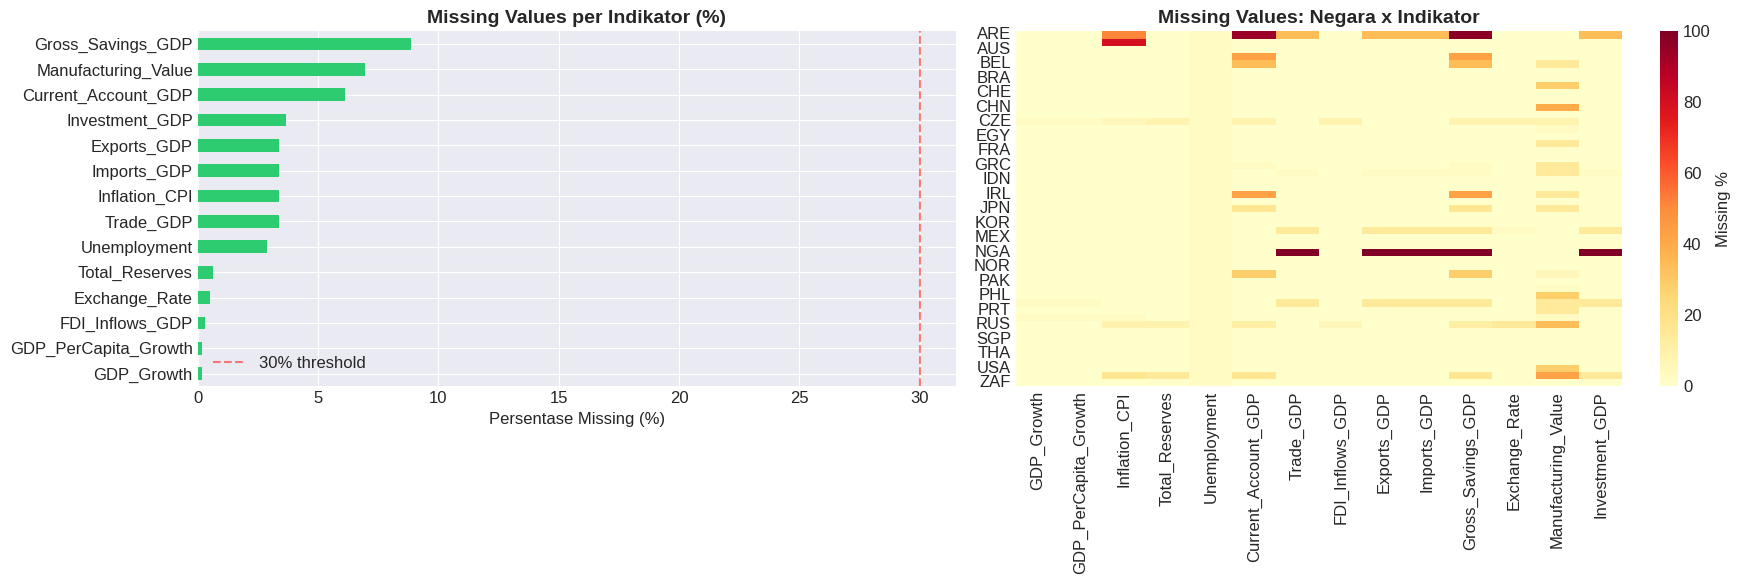

In [78]:
# ============================================================
# 2.2 Visualisasi Missing Values
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar plot missing values
missing_pct = (df[feature_cols].isnull().sum() / len(df) * 100).sort_values(ascending=True)
colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 15 else '#2ecc71' for x in missing_pct]
missing_pct.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Missing Values per Indikator (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Persentase Missing (%)')
axes[0].axvline(x=30, color='red', linestyle='--', alpha=0.5, label='30% threshold')
axes[0].legend()

# Missing per negara (heatmap)
pivot_miss = df.groupby('economy')[feature_cols].apply(lambda x: x.isnull().mean() * 100)
sns.heatmap(pivot_miss, cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Missing %'})
axes[1].set_title('Missing Values: Negara x Indikator', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('eda_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

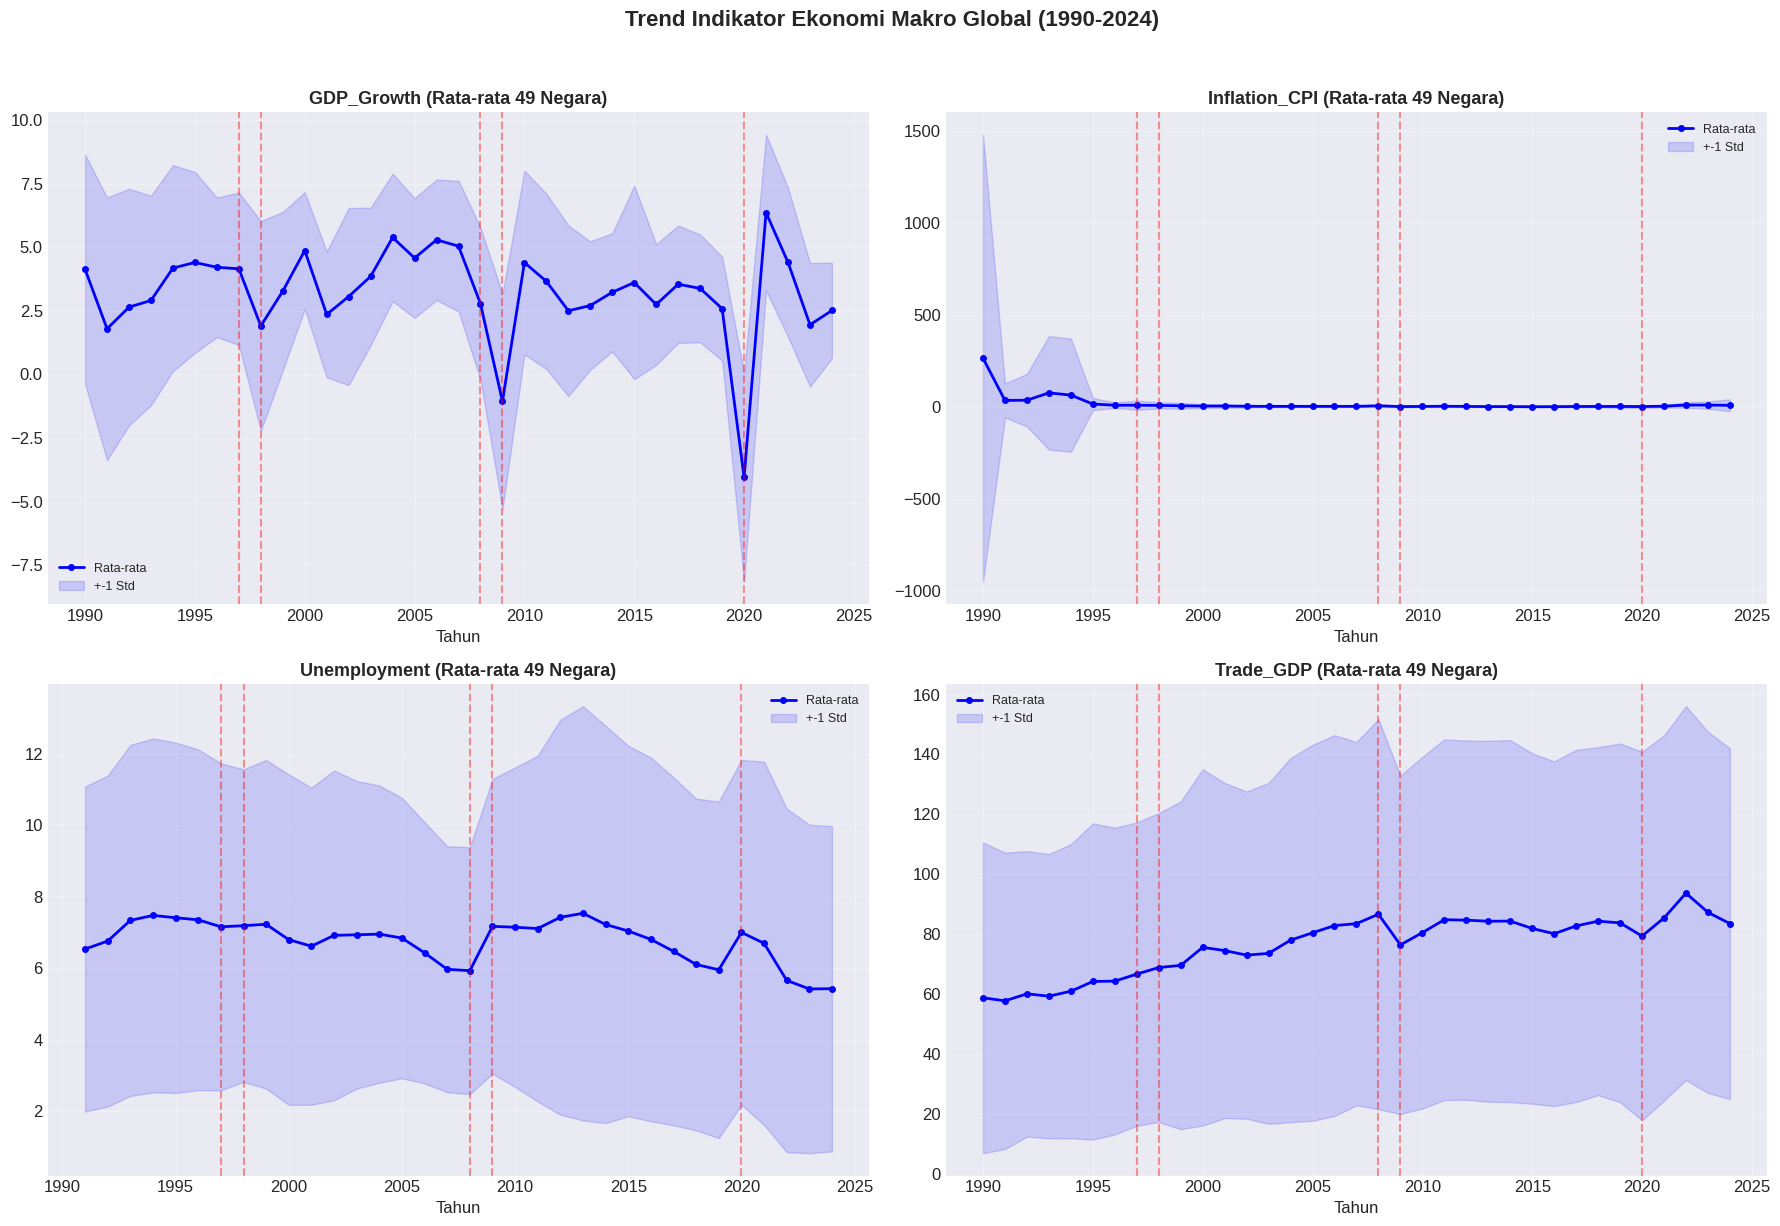

In [79]:
# ============================================================
# 2.3 Trend Indikator Utama (Rata-rata Global)
# ============================================================
key_indicators = ['GDP_Growth', 'Inflation_CPI', 'Unemployment', 'Trade_GDP']
crisis_years_mark = [1997, 1998, 2008, 2009, 2020]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, ind in enumerate(key_indicators):
    if ind not in df.columns:
        continue
    avg = df.groupby('year')[ind].mean()
    std = df.groupby('year')[ind].std()

    axes[idx].plot(avg.index, avg.values, 'b-o', linewidth=2, markersize=4, label='Rata-rata')
    axes[idx].fill_between(avg.index, avg - std, avg + std, alpha=0.15, color='blue', label='+-1 Std')

    # Highlight crisis years
    for cy in crisis_years_mark:
        if cy in avg.index:
            axes[idx].axvline(x=cy, color='red', linestyle='--', alpha=0.4)

    axes[idx].set_title(f'{ind} (Rata-rata {len(countries)} Negara)', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Tahun')
    axes[idx].legend(loc='best', fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Trend Indikator Ekonomi Makro Global (1990-2024)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_trends.png', dpi=150, bbox_inches='tight')
plt.show()

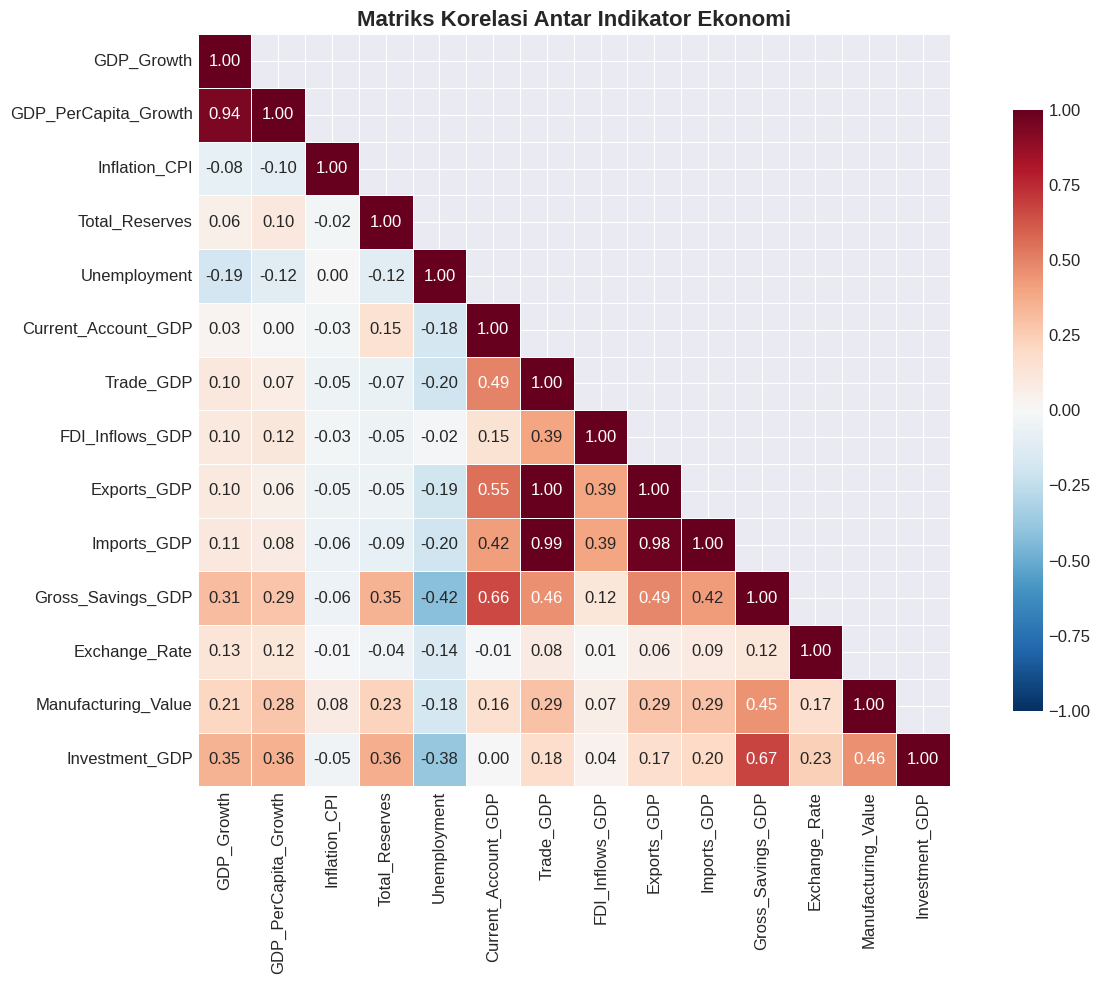


Korelasi tinggi (|r| > 0.7):
   GDP_Growth <-> GDP_PerCapita_Growth: 0.943
   Trade_GDP <-> Exports_GDP: 0.995
   Trade_GDP <-> Imports_GDP: 0.994
   Exports_GDP <-> Imports_GDP: 0.978


In [80]:
# ============================================================
# 2.4 Correlation Heatmap
# ============================================================
fig, ax = plt.subplots(figsize=(14, 10))

corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr), k=1)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Matriks Korelasi Antar Indikator Ekonomi', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKorelasi tinggi (|r| > 0.7):")
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.7:
            print(f"   {corr.index[i]} <-> {corr.columns[j]}: {corr.iloc[i, j]:.3f}")

---
## 3. Pre-processing & Feature Engineering

- **Handling Missing Values:** Interpolasi linear per negara + forward/backward fill
- **Filtering:** Hapus kolom dengan >50% missing dan baris yang masih missing
- **Scaling:** StandardScaler (Z-score normalization) — **wajib** karena satuan antar indikator sangat berbeda

In [81]:
# ============================================================
# 3.1 Handling Missing Values
# ============================================================
print("Pre-processing data...")
print(f"   Missing values SEBELUM: {df[feature_cols].isnull().sum().sum():,}")

# Drop kolom dengan >50% missing
high_missing = [c for c in feature_cols if df[c].isnull().mean() > 0.5]
if high_missing:
    print(f"   Menghapus kolom >50% missing: {high_missing}")
    feature_cols = [c for c in feature_cols if c not in high_missing]

# Interpolasi per negara
df_clean = df.copy()
for country in df_clean['economy'].unique():
    mask = df_clean['economy'] == country
    df_clean.loc[mask, feature_cols] = (
        df_clean.loc[mask, feature_cols]
        .interpolate(method='linear', limit_direction='both')
        .ffill()
        .bfill()
    )

# Drop baris yang masih ada missing
df_clean = df_clean.dropna(subset=feature_cols).reset_index(drop=True)

print(f"   Missing values SESUDAH: {df_clean[feature_cols].isnull().sum().sum()}")
print(f"   Baris tersisa: {len(df_clean):,} (dari {len(df):,})")
print(f"   Negara tersisa: {df_clean['economy'].nunique()}")
print(f"   Fitur tersisa: {len(feature_cols)}")

Pre-processing data...
   Missing values SEBELUM: 751
   Missing values SESUDAH: 0
   Baris tersisa: 1,680 (dari 1,715)
   Negara tersisa: 48
   Fitur tersisa: 14


In [82]:
# ============================================================
# 3.2 Normalisasi dengan StandardScaler
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[feature_cols])

# Simpan metadata (economy, year) yang sejajar dengan X_scaled
meta = df_clean[['economy', 'year']].reset_index(drop=True)

print("Data berhasil dinormalisasi (StandardScaler)")
print(f"   Shape X_scaled: {X_scaled.shape}")
print(f"   Mean ~= 0: {np.round(X_scaled.mean(axis=0), 2)}")
print(f"   Std  ~= 1: {np.round(X_scaled.std(axis=0), 2)}")

Data berhasil dinormalisasi (StandardScaler)
   Shape X_scaled: (1680, 14)
   Mean ~= 0: [ 0. -0. -0.  0. -0. -0. -0. -0. -0.  0.  0.  0.  0. -0.]
   Std  ~= 1: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
## 4. Dimensionality Reduction (Reduksi Dimensi)

- **PCA (Principal Component Analysis):** Mereduksi dimensi sambil mempertahankan varians terbesar. Memudahkan visualisasi dan menghindari *curse of dimensionality*.
- **t-SNE:** Teknik non-linear untuk visualisasi 2D — melihat apakah data tahun krisis terpisah dari data normal.

Komponen untuk 80% variance: 6
Komponen untuk 90% variance: 8


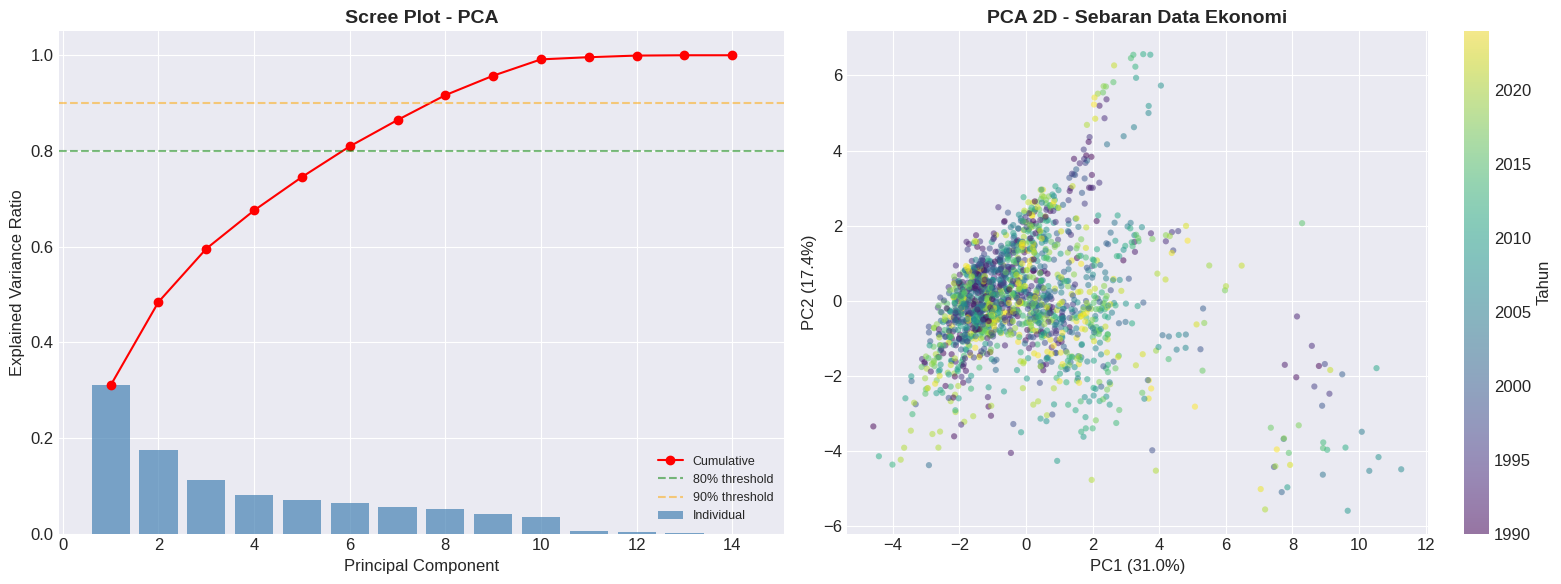

In [83]:
# ============================================================
# 4.1 PCA (Principal Component Analysis)
# ============================================================
# PCA full untuk melihat explained variance
pca_full = PCA()
pca_full.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree Plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, alpha=0.7, color='steelblue', label='Individual')
axes[0].plot(range(1, len(pca_full.explained_variance_ratio_)+1),
             np.cumsum(pca_full.explained_variance_ratio_), 'ro-', label='Cumulative')
axes[0].axhline(y=0.80, color='green', linestyle='--', alpha=0.5, label='80% threshold')
axes[0].axhline(y=0.90, color='orange', linestyle='--', alpha=0.5, label='90% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot - PCA', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9)

n_80 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.80) + 1
n_90 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.90) + 1
print(f"Komponen untuk 80% variance: {n_80}")
print(f"Komponen untuk 90% variance: {n_90}")

# PCA 2D scatter
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=meta['year'], cmap='viridis', alpha=0.5, s=20, edgecolors='none')
plt.colorbar(scatter, ax=axes[1], label='Tahun')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('PCA 2D - Sebaran Data Ekonomi', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

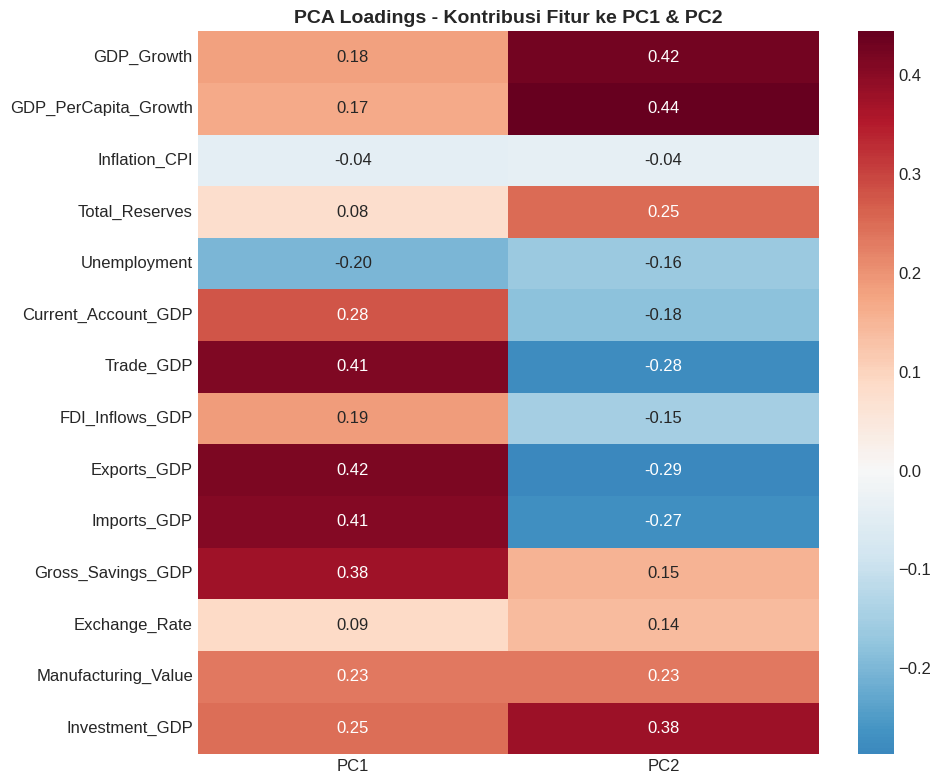

Fitur dengan loading terbesar pada PC1:
Exports_GDP            0.416342
Trade_GDP              0.413669
Imports_GDP            0.405602
Gross_Savings_GDP      0.375341
Current_Account_GDP    0.281360
Name: PC1, dtype: float64


In [84]:
# ============================================================
# PCA Loadings (Kontribusi setiap fitur ke PC)
# ============================================================
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_cols
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('PCA Loadings - Kontribusi Fitur ke PC1 & PC2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Fitur dengan loading terbesar pada PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

Menjalankan t-SNE (membutuhkan beberapa saat)...


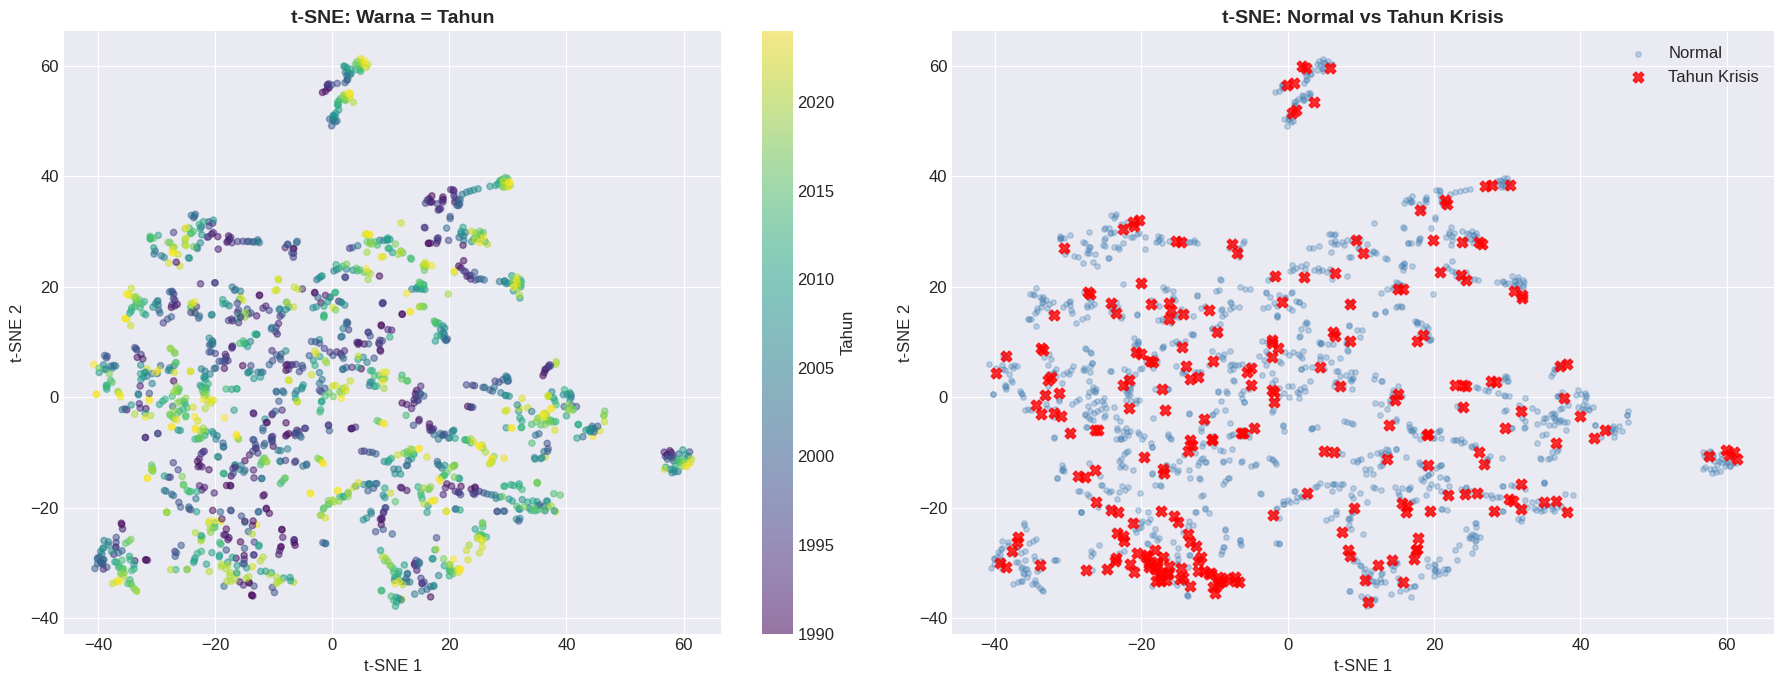

t-SNE selesai! Perhatikan apakah titik merah (krisis) terpisah dari biru (normal).


In [85]:
# ============================================================
# 4.2 t-SNE Visualization
# ============================================================
print("Menjalankan t-SNE (membutuhkan beberapa saat)...")

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000, learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)

# Definisikan tahun krisis
crisis_years_set = {1997, 1998, 2008, 2009, 2020}
is_crisis = meta['year'].isin(crisis_years_set)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Warna = tahun
scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                           c=meta['year'], cmap='viridis', alpha=0.5, s=20)
plt.colorbar(scatter1, ax=axes[0], label='Tahun')
axes[0].set_title('t-SNE: Warna = Tahun', fontsize=14, fontweight='bold')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

# Plot 2: Normal vs Crisis
axes[1].scatter(X_tsne[~is_crisis, 0], X_tsne[~is_crisis, 1],
                c='steelblue', alpha=0.3, s=15, label='Normal')
axes[1].scatter(X_tsne[is_crisis, 0], X_tsne[is_crisis, 1],
                c='red', alpha=0.8, s=60, marker='X', label='Tahun Krisis')
axes[1].set_title('t-SNE: Normal vs Tahun Krisis', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.savefig('tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("t-SNE selesai! Perhatikan apakah titik merah (krisis) terpisah dari biru (normal).")

---
## 5. Model Implementation (Deteksi Anomali)

Menerapkan 3 algoritma *unsupervised learning*:

1. **Isolation Forest** — Random partitioning; anomali terisolasi lebih cepat (jalur lebih pendek)
2. **Local Outlier Factor (LOF)** — Density-based; kepadatan lokal rendah = anomali
3. **Autoencoder (Neural Network)** — Reconstruction error tinggi = anomali

> *"Isolation Forest dipilih karena ketangguhannya terhadap data berdimensi tinggi dan tidak mengasumsikan distribusi normal pada data ekonomi."*

In [86]:
# ============================================================
# 5.1 Isolation Forest
# ============================================================
print("Training Isolation Forest...")

if_model = IsolationForest(
    n_estimators=200,
    contamination=0.08,  # ~8% data dianggap anomali
    random_state=42,
    n_jobs=-1
)

if_labels = if_model.fit_predict(X_scaled)
if_scores = if_model.decision_function(X_scaled)

# Konversi: -1 -> 1 (anomali), 1 -> 0 (normal)
if_anomaly = (if_labels == -1).astype(int)

n_anom = if_anomaly.sum()
print(f"Isolation Forest selesai!")
print(f"   Anomali terdeteksi: {n_anom} ({n_anom/len(if_anomaly)*100:.1f}%)")

# Top anomali
anomaly_if_df = meta.copy()
anomaly_if_df['anomaly'] = if_anomaly
anomaly_if_df['score'] = if_scores

print(f"\nTop 15 data paling anomali (Isolation Forest):")
for _, row in anomaly_if_df.nsmallest(15, 'score').iterrows():
    print(f"   {row['economy']} - {row['year']}  (score: {row['score']:.4f})")

Training Isolation Forest...
Isolation Forest selesai!
   Anomali terdeteksi: 135 (8.0%)

Top 15 data paling anomali (Isolation Forest):
   SGP - 2010  (score: -0.1530)
   SGP - 2006  (score: -0.1518)
   IRL - 2015  (score: -0.1411)
   SGP - 2007  (score: -0.1400)
   SGP - 2020  (score: -0.1327)
   SGP - 2021  (score: -0.1297)
   SGP - 2004  (score: -0.1286)
   SGP - 2005  (score: -0.1282)
   SGP - 2003  (score: -0.1242)
   SGP - 1998  (score: -0.1215)
   SGP - 2011  (score: -0.1181)
   SGP - 2000  (score: -0.1149)
   SGP - 2012  (score: -0.1123)
   SGP - 2023  (score: -0.1121)
   SGP - 2008  (score: -0.1108)


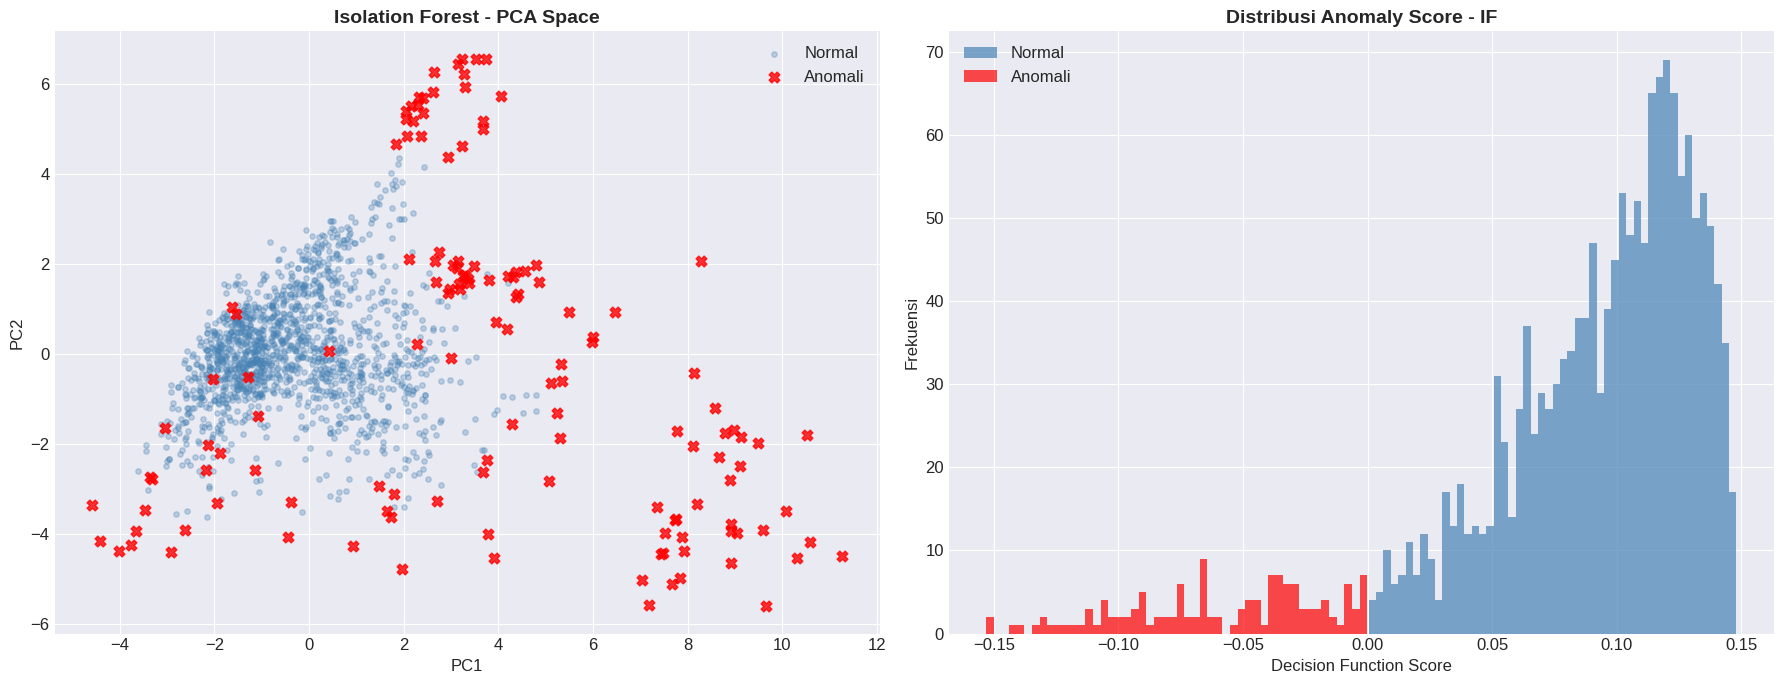

In [87]:
# Visualisasi Isolation Forest
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

normal_mask = if_anomaly == 0
axes[0].scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
                c='steelblue', alpha=0.3, s=15, label='Normal')
axes[0].scatter(X_pca[~normal_mask, 0], X_pca[~normal_mask, 1],
                c='red', alpha=0.8, s=60, marker='X', label='Anomali')
axes[0].set_title('Isolation Forest - PCA Space', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

axes[1].hist(if_scores[normal_mask], bins=50, alpha=0.7, label='Normal', color='steelblue')
axes[1].hist(if_scores[~normal_mask], bins=50, alpha=0.7, label='Anomali', color='red')
axes[1].set_title('Distribusi Anomaly Score - IF', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Decision Function Score')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout()
plt.savefig('isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()

In [88]:
# ============================================================
# 5.2 Local Outlier Factor (LOF)
# ============================================================
print("Training Local Outlier Factor...")

lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.08,
    novelty=False
)

lof_labels = lof_model.fit_predict(X_scaled)
lof_scores = lof_model.negative_outlier_factor_

# Konversi: -1 -> 1 (anomali)
lof_anomaly = (lof_labels == -1).astype(int)

n_anom = lof_anomaly.sum()
print(f"LOF selesai!")
print(f"   Anomali terdeteksi: {n_anom} ({n_anom/len(lof_anomaly)*100:.1f}%)")

anomaly_lof_df = meta.copy()
anomaly_lof_df['anomaly'] = lof_anomaly
anomaly_lof_df['score'] = lof_scores

print(f"\nTop 15 data paling anomali (LOF):")
for _, row in anomaly_lof_df.nsmallest(15, 'score').iterrows():
    print(f"   {row['economy']} - {row['year']}  (LOF score: {row['score']:.4f})")

Training Local Outlier Factor...
LOF selesai!
   Anomali terdeteksi: 135 (8.0%)

Top 15 data paling anomali (LOF):
   PER - 1990  (LOF score: -10.6138)
   BRA - 1994  (LOF score: -4.4142)
   BRA - 1990  (LOF score: -4.2155)
   BRA - 1993  (LOF score: -4.1796)
   HUN - 2020  (LOF score: -2.8163)
   IRL - 2015  (LOF score: -2.7409)
   BRA - 1992  (LOF score: -2.2322)
   RUS - 1990  (LOF score: -2.1728)
   IRL - 2019  (LOF score: -2.1395)
   NLD - 2007  (LOF score: -2.0736)
   KEN - 1994  (LOF score: -2.0102)
   RUS - 1991  (LOF score: -1.9626)
   KEN - 1993  (LOF score: -1.9276)
   IDN - 1999  (LOF score: -1.9184)
   CHN - 2007  (LOF score: -1.9122)


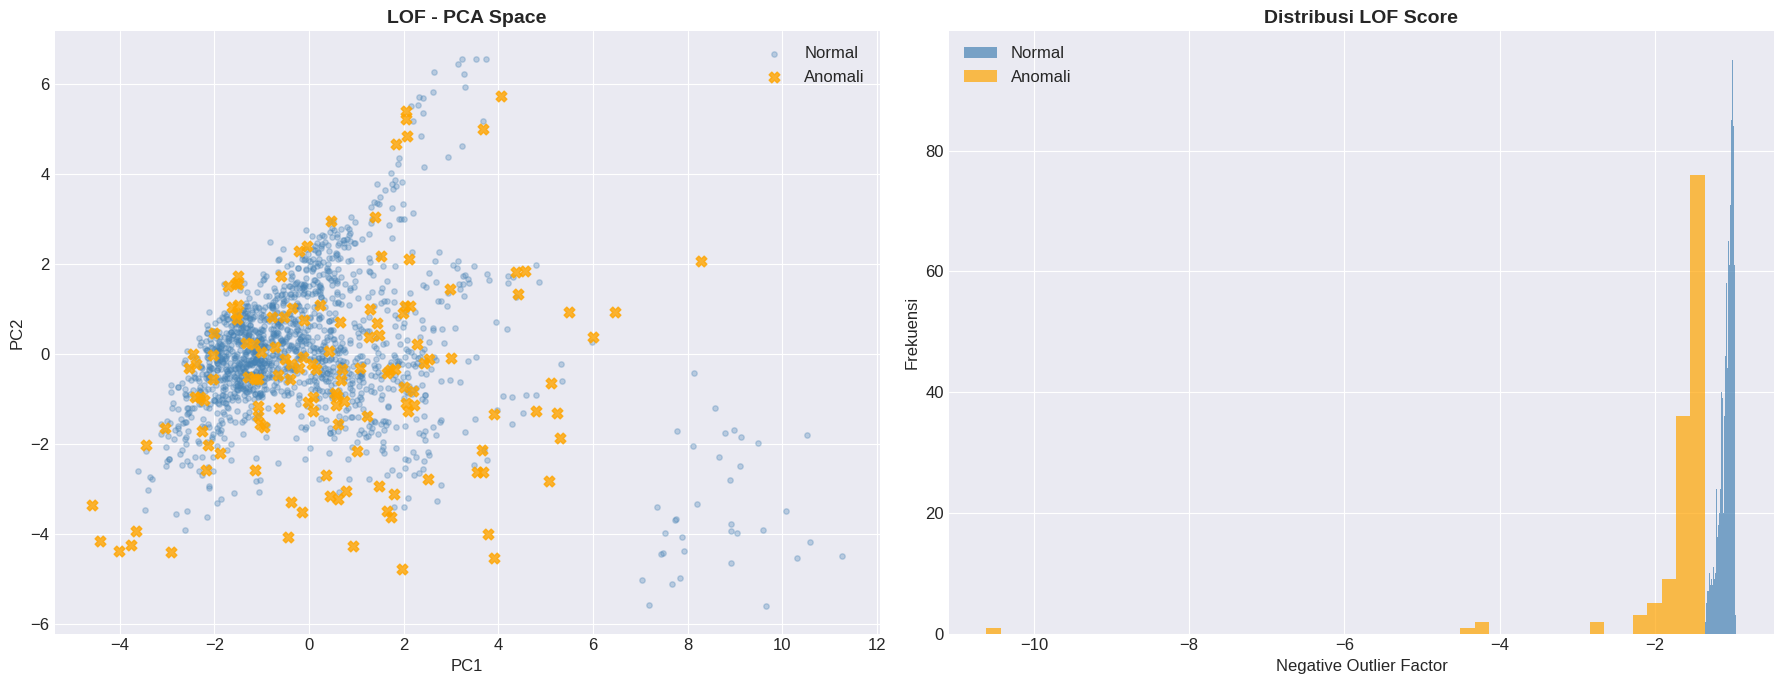

In [89]:
# Visualisasi LOF
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

normal_mask = lof_anomaly == 0
axes[0].scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
                c='steelblue', alpha=0.3, s=15, label='Normal')
axes[0].scatter(X_pca[~normal_mask, 0], X_pca[~normal_mask, 1],
                c='orange', alpha=0.8, s=60, marker='X', label='Anomali')
axes[0].set_title('LOF - PCA Space', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

axes[1].hist(lof_scores[normal_mask], bins=50, alpha=0.7, label='Normal', color='steelblue')
axes[1].hist(lof_scores[~normal_mask], bins=50, alpha=0.7, label='Anomali', color='orange')
axes[1].set_title('Distribusi LOF Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Negative Outlier Factor')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout()
plt.savefig('lof_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [90]:
# ============================================================
# 5.3 Autoencoder (Neural Network)
# ============================================================
if HAS_TF:
    print("Training Autoencoder...")
    n_features = X_scaled.shape[1]

    # Arsitektur Autoencoder
    encoder_input = keras.Input(shape=(n_features,))
    # Encoder
    x = layers.Dense(32, activation='relu')(encoder_input)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation='relu')(x)
    x = layers.Dense(8, activation='relu')(x)     # Bottleneck
    # Decoder
    x = layers.Dense(16, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    decoder_output = layers.Dense(n_features, activation='linear')(x)

    autoencoder = keras.Model(encoder_input, decoder_output)
    autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')

    autoencoder.summary()
else:
    print("TensorFlow tidak tersedia. Autoencoder di-skip.")
    print("Akan menggunakan hasil IF dan LOF saja untuk evaluasi.")

Training Autoencoder...


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 14)             │           462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422 (9.46 KB)

 Trainable params: 2,358 (9.21 KB)

 Non-trainable params: 64 (256.00 B)

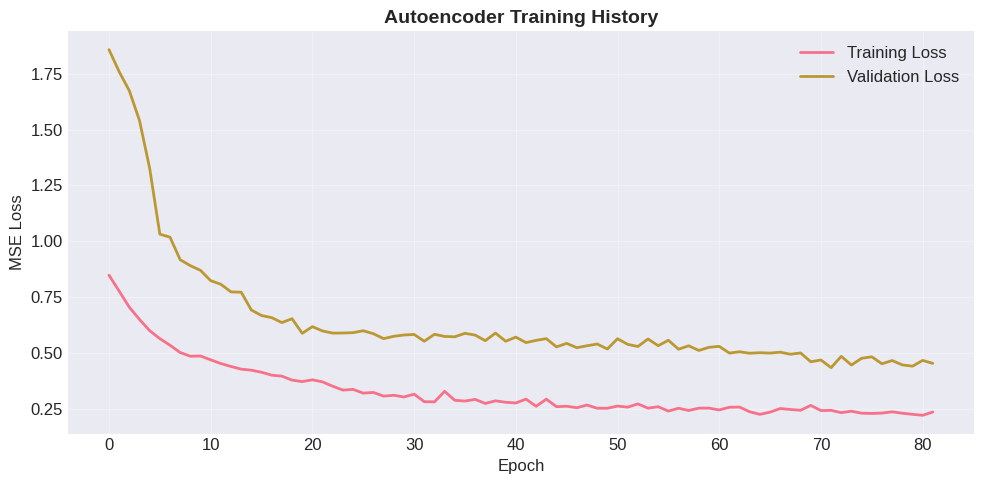

Final Training Loss   : 0.234743
Final Validation Loss : 0.452695


In [91]:
# Training Autoencoder
if HAS_TF:
    history = autoencoder.fit(
        X_scaled, X_scaled,
        epochs=100,
        batch_size=32,
        validation_split=0.15,
        shuffle=True,
        verbose=0,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
        ]
    )

    # Plot training history
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title('Autoencoder Training History', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Final Training Loss   : {history.history['loss'][-1]:.6f}")
    print(f"Final Validation Loss : {history.history['val_loss'][-1]:.6f}")

In [92]:
# Deteksi Anomali dengan Reconstruction Error
if HAS_TF:
    X_reconstructed = autoencoder.predict(X_scaled, verbose=0)
    reconstruction_error = np.mean(np.square(X_scaled - X_reconstructed), axis=1)

    # Threshold: percentile ke-92 (~8% anomali)
    ae_threshold = np.percentile(reconstruction_error, 92)
    ae_anomaly = (reconstruction_error > ae_threshold).astype(int)

    n_anom = ae_anomaly.sum()
    print(f"Autoencoder Anomaly Detection selesai!")
    print(f"   Threshold MSE   : {ae_threshold:.6f}")
    print(f"   Anomali terdeteksi: {n_anom} ({n_anom/len(ae_anomaly)*100:.1f}%)")

    anomaly_ae_df = meta.copy()
    anomaly_ae_df['anomaly'] = ae_anomaly
    anomaly_ae_df['score'] = reconstruction_error

    print(f"\nTop 15 anomali (highest reconstruction error):")
    for _, row in anomaly_ae_df.nlargest(15, 'score').iterrows():
        print(f"   {row['economy']} - {row['year']}  (MSE: {row['score']:.4f})")
else:
    ae_anomaly = np.zeros(len(X_scaled), dtype=int)
    reconstruction_error = np.zeros(len(X_scaled))
    ae_threshold = 0

Autoencoder Anomaly Detection selesai!
   Threshold MSE   : 0.366352
   Anomali terdeteksi: 135 (8.0%)

Top 15 anomali (highest reconstruction error):
   PER - 1990  (MSE: 8.6302)
   VNM - 2024  (MSE: 3.5032)
   VNM - 2023  (MSE: 2.9985)
   VNM - 2022  (MSE: 2.9848)
   VNM - 2021  (MSE: 2.8567)
   VNM - 2019  (MSE: 2.8301)
   VNM - 2020  (MSE: 2.6687)
   VNM - 2018  (MSE: 2.6674)
   IRL - 2015  (MSE: 2.6620)
   HUN - 2018  (MSE: 2.6382)
   VNM - 2017  (MSE: 2.4261)
   VNM - 2016  (MSE: 2.1921)
   VNM - 2014  (MSE: 2.1818)
   VNM - 2015  (MSE: 2.1661)
   VNM - 2013  (MSE: 2.0009)


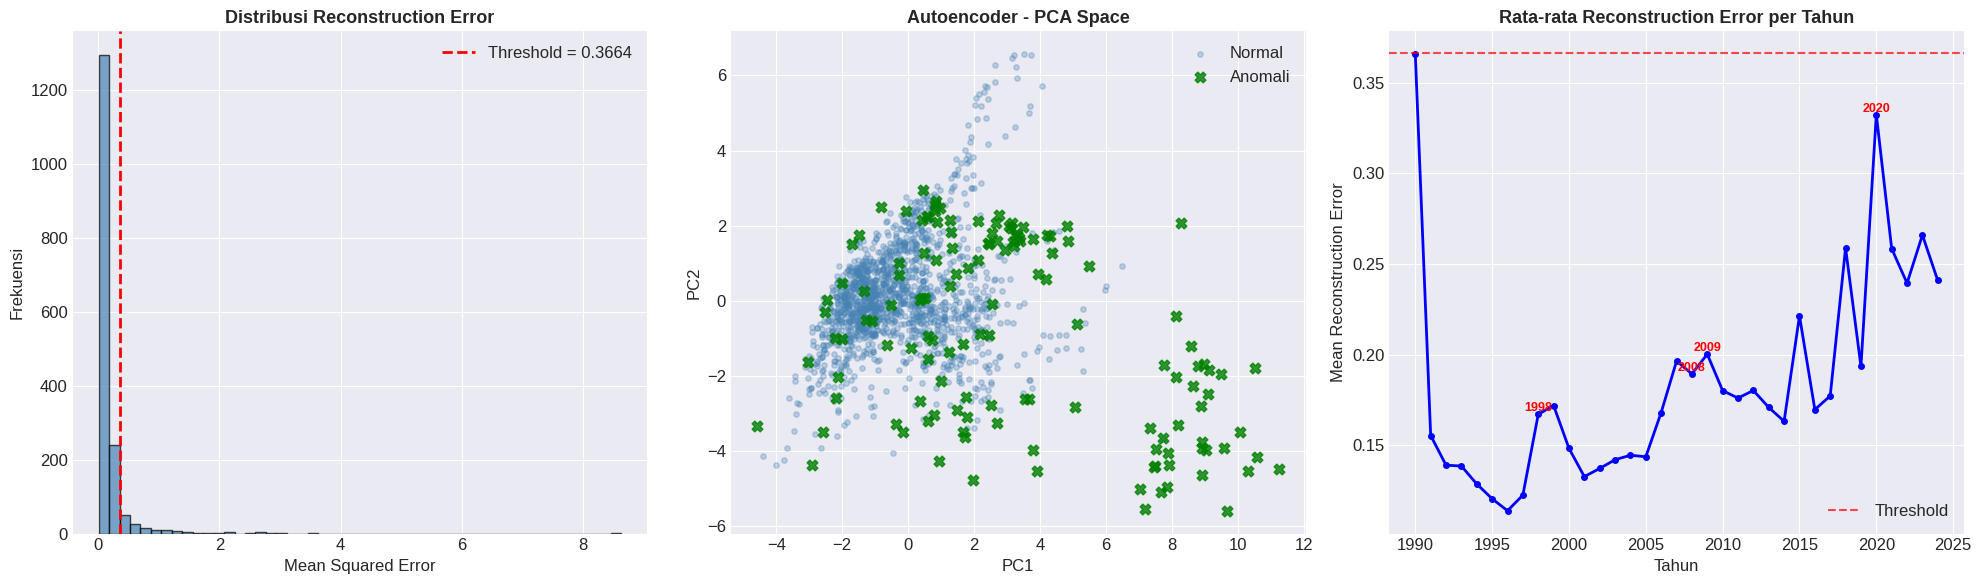

In [93]:
# Visualisasi Autoencoder
if HAS_TF:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Distribusi Reconstruction Error
    axes[0].hist(reconstruction_error, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[0].axvline(x=ae_threshold, color='red', linestyle='--', linewidth=2,
                    label=f'Threshold = {ae_threshold:.4f}')
    axes[0].set_title('Distribusi Reconstruction Error', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Mean Squared Error')
    axes[0].set_ylabel('Frekuensi')
    axes[0].legend()

    # Anomali di PCA space
    normal_mask = ae_anomaly == 0
    axes[1].scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
                    c='steelblue', alpha=0.3, s=15, label='Normal')
    axes[1].scatter(X_pca[~normal_mask, 0], X_pca[~normal_mask, 1],
                    c='green', alpha=0.8, s=60, marker='X', label='Anomali')
    axes[1].set_title('Autoencoder - PCA Space', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel('PC2')
    axes[1].legend()

    # Rata-rata reconstruction error per tahun
    yearly_err = pd.DataFrame({'year': meta['year'], 'error': reconstruction_error})
    yearly_avg = yearly_err.groupby('year')['error'].mean()
    axes[2].plot(yearly_avg.index, yearly_avg.values, 'b-o', linewidth=2, markersize=4)
    axes[2].axhline(y=ae_threshold, color='red', linestyle='--', alpha=0.7, label='Threshold')
    for cy in [1998, 2008, 2009, 2020]:
        if cy in yearly_avg.index:
            axes[2].annotate(str(cy), xy=(cy, yearly_avg[cy]), fontsize=9,
                            color='red', fontweight='bold', ha='center', va='bottom')
    axes[2].set_title('Rata-rata Reconstruction Error per Tahun', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Tahun')
    axes[2].set_ylabel('Mean Reconstruction Error')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('autoencoder_results.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 6. Model Comparison (Perbandingan Model)

Membandingkan tahun dan negara mana yang terdeteksi anomali oleh setiap model, serta menganalisis konsensus/overlap.

In [94]:
# ============================================================
# 6.1 Tabel Perbandingan per Tahun
# ============================================================
comparison = meta.copy()
comparison['IF'] = if_anomaly
comparison['LOF'] = lof_anomaly
comparison['AE'] = ae_anomaly
comparison['Total_Models'] = comparison['IF'] + comparison['LOF'] + comparison['AE']

# Ringkasan per tahun
yearly_summary = comparison.groupby('year').agg(
    IF_count=('IF', 'sum'),
    LOF_count=('LOF', 'sum'),
    AE_count=('AE', 'sum'),
    Total=('Total_Models', 'sum'),
    Countries_Anomaly=('Total_Models', lambda x: (x > 0).sum())
).reset_index()

print("Jumlah Anomali Terdeteksi per Tahun:")
print("=" * 70)
print(yearly_summary.nlargest(15, 'Total').to_string(index=False))

Jumlah Anomali Terdeteksi per Tahun:
 year  IF_count  LOF_count  AE_count  Total  Countries_Anomaly
 2020        12          9         9     30                 17
 1990         6         10         7     23                 11
 2009         5          8         7     20                 12
 2021         4          9         5     18                 13
 2022         4          8         6     18                 11
 2023         4          5         6     15                  8
 2024         5          5         5     15                  9
 1991         3          7         4     14                  8
 1993         4          5         5     14                  9
 1998         3          5         6     14                  7
 1999         3          6         5     14                 10
 1992         5          5         3     13                  8
 2012         6          4         3     13                  7
 2008         4          4         4     12                  7
 2011         6   

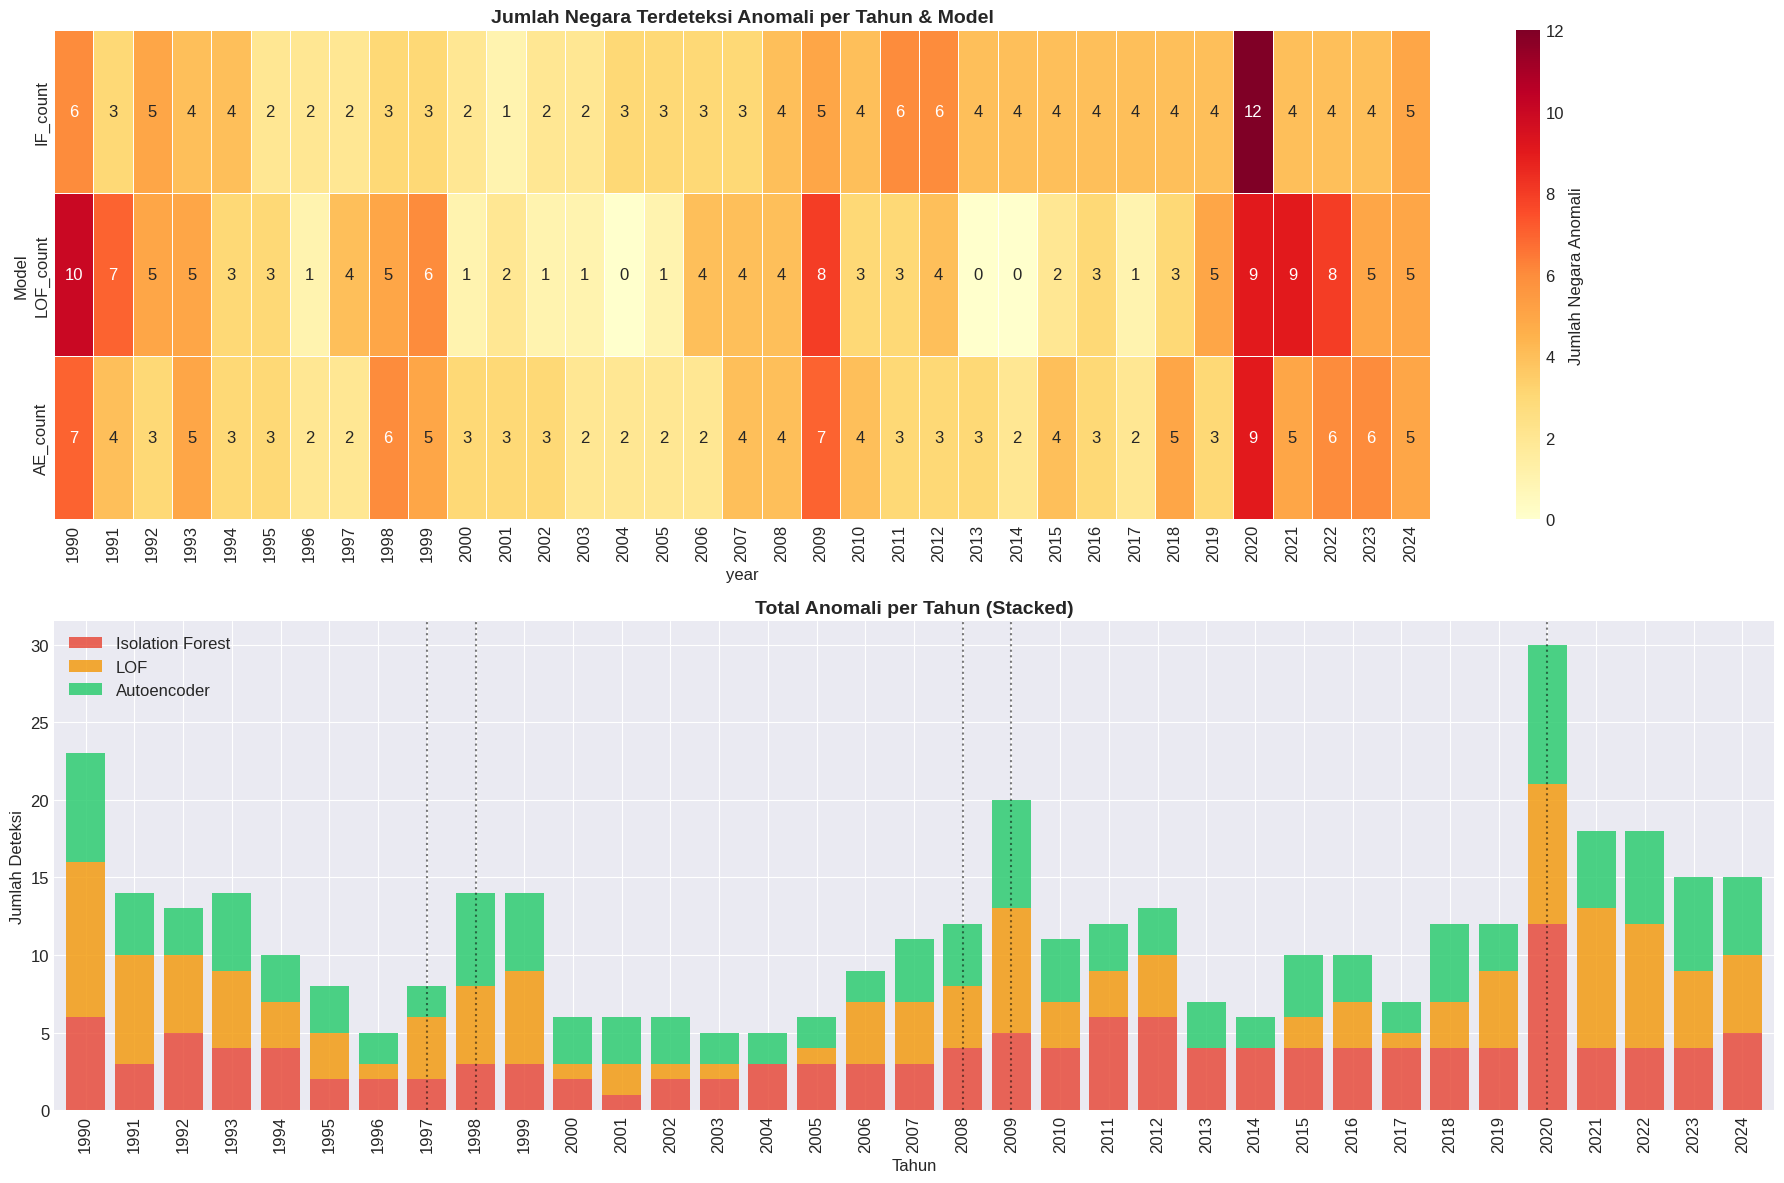

In [95]:
# ============================================================
# 6.2 Visualisasi Perbandingan
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# Heatmap per tahun
yearly_ht = yearly_summary[['year', 'IF_count', 'LOF_count', 'AE_count']].set_index('year').T
sns.heatmap(yearly_ht, cmap='YlOrRd', annot=True, fmt='g', ax=axes[0],
            cbar_kws={'label': 'Jumlah Negara Anomali'}, linewidths=0.5)
axes[0].set_title('Jumlah Negara Terdeteksi Anomali per Tahun & Model', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Model')

# Stacked bar chart
yearly_bar = yearly_summary[['year', 'IF_count', 'LOF_count', 'AE_count']].set_index('year')
yearly_bar.plot(kind='bar', stacked=True, ax=axes[1],
                color=['#e74c3c', '#f39c12', '#2ecc71'], alpha=0.85, width=0.8)
axes[1].set_title('Total Anomali per Tahun (Stacked)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('Jumlah Deteksi')
axes[1].legend(['Isolation Forest', 'LOF', 'Autoencoder'], loc='upper left')

# Highlight crisis years
for cy in [1997, 1998, 2008, 2009, 2020]:
    if cy in yearly_bar.index:
        idx = list(yearly_bar.index).index(cy)
        axes[1].axvline(x=idx, color='black', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [96]:
# ============================================================
# 6.3 Analisis Konsensus
# ============================================================
# Data yang terdeteksi oleh >= 2 model
consensus = comparison[comparison['Total_Models'] >= 2].copy()
print(f"Data terdeteksi anomali oleh >= 2 model: {len(consensus)}")

print(f"\nBreakdown per negara (top 15):")
print(consensus.groupby('economy').size().sort_values(ascending=False).head(15).to_string())

print(f"\nBreakdown per tahun (top 10):")
print(consensus.groupby('year').size().sort_values(ascending=False).head(10).to_string())

# Overlap analysis
only_if = ((comparison['IF']==1) & (comparison['LOF']==0) & (comparison['AE']==0)).sum()
only_lof = ((comparison['IF']==0) & (comparison['LOF']==1) & (comparison['AE']==0)).sum()
only_ae = ((comparison['IF']==0) & (comparison['LOF']==0) & (comparison['AE']==1)).sum()
if_lof = ((comparison['IF']==1) & (comparison['LOF']==1) & (comparison['AE']==0)).sum()
if_ae = ((comparison['IF']==1) & (comparison['LOF']==0) & (comparison['AE']==1)).sum()
lof_ae = ((comparison['IF']==0) & (comparison['LOF']==1) & (comparison['AE']==1)).sum()
all_three = ((comparison['IF']==1) & (comparison['LOF']==1) & (comparison['AE']==1)).sum()

print(f"\nOverlap antar model:")
print(f"   Hanya IF       : {only_if}")
print(f"   Hanya LOF      : {only_lof}")
print(f"   Hanya AE       : {only_ae}")
print(f"   IF + LOF       : {if_lof}")
print(f"   IF + AE        : {if_ae}")
print(f"   LOF + AE       : {lof_ae}")
print(f"   IF + LOF + AE  : {all_three}")

Data terdeteksi anomali oleh >= 2 model: 134

Breakdown per negara (top 15):
economy
SGP    34
VNM    22
IRL    15
HUN     7
CHN     6
MYS     6
SAU     4
ARG     4
BRA     4
ROU     4
KEN     4
NLD     4
GRC     4
CHE     3
ARE     3

Breakdown per tahun (top 10):
year
2020    10
1990     7
2023     6
2009     6
2022     6
1992     5
1991     5
1993     5
1998     5
2008     5

Overlap antar model:
   Hanya IF       : 29
   Hanya LOF      : 58
   Hanya AE       : 28
   IF + LOF       : 27
   IF + AE        : 57
   LOF + AE       : 28
   IF + LOF + AE  : 22


---
## 7. Evaluation & Interpretation (Validasi)

Evaluasi model dengan membandingkan hasil deteksi terhadap **ground truth** krisis ekonomi historis.

| Tahun | Krisis | Negara Terdampak Utama |
|---|---|---|
| 1997-1998 | Krisis Keuangan Asia | IDN, THA, MYS, KOR, PHL |
| 2001-2002 | Krisis Argentina | ARG |
| 2008-2009 | Global Financial Crisis | Seluruh dunia |
| 2010-2012 | Krisis Utang Eropa | GRC, PRT, IRL, ESP, ITA |
| 2014-2016 | Jatuhnya Harga Komoditas | BRA, RUS, NGA, SAU, COL |
| 2020 | Pandemi COVID-19 | Seluruh dunia |

In [97]:
# ============================================================
# 7.1 Definisi Ground Truth Krisis Historis
# ============================================================
crisis_ground_truth = set()

# 1997-1998: Asian Financial Crisis
for c in ['IDN', 'THA', 'MYS', 'KOR', 'PHL']:
    for y in [1997, 1998]:
        crisis_ground_truth.add((c, y))

# 2001-2002: Argentina Crisis
for y in [2001, 2002]:
    crisis_ground_truth.add(('ARG', y))

# 2008-2009: Global Financial Crisis (semua negara)
for c in meta['economy'].unique():
    for y in [2008, 2009]:
        crisis_ground_truth.add((c, y))

# 2010-2012: European Debt Crisis
for c in ['GRC', 'PRT', 'IRL', 'ESP', 'ITA']:
    for y in [2010, 2011, 2012]:
        crisis_ground_truth.add((c, y))

# 2014-2016: Commodity Crash
for c in ['BRA', 'RUS', 'NGA', 'SAU', 'COL']:
    for y in [2014, 2015, 2016]:
        crisis_ground_truth.add((c, y))

# 2020: COVID-19 Pandemic (semua negara)
for c in meta['economy'].unique():
    crisis_ground_truth.add((c, 2020))

# Buat label array y_true
y_true = np.array([
    1 if (row['economy'], row['year']) in crisis_ground_truth else 0
    for _, row in meta.iterrows()
])

print(f"Ground Truth Krisis:")
print(f"   Total data       : {len(y_true):,}")
print(f"   Krisis (label=1) : {y_true.sum():,} ({y_true.mean()*100:.1f}%)")
print(f"   Normal (label=0) : {(y_true==0).sum():,} ({(1-y_true.mean())*100:.1f}%)")

Ground Truth Krisis:
   Total data       : 1,680
   Krisis (label=1) : 183 (10.9%)
   Normal (label=0) : 1,497 (89.1%)


In [98]:
# ============================================================
# 7.2 Performance Metrics
# ============================================================
models_eval = {
    'Isolation Forest': if_anomaly,
    'LOF': lof_anomaly,
    'Autoencoder': ae_anomaly
}

print("Performance Metrics vs Ground Truth Krisis")
print("=" * 70)

results_list = []

for model_name, y_pred in models_eval.items():
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    tp = ((y_true==1) & (y_pred==1)).sum()
    fp = ((y_true==0) & (y_pred==1)).sum()
    fn = ((y_true==1) & (y_pred==0)).sum()
    tn = ((y_true==0) & (y_pred==0)).sum()

    results_list.append({
        'Model': model_name,
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
    })

    print(f"\n{'_' * 40}")
    print(f"  {model_name}")
    print(f"   Precision : {prec:.4f}")
    print(f"   Recall    : {rec:.4f}")
    print(f"   F1-Score  : {f1:.4f}")
    print(f"   TP={tp}, FP={fp}, FN={fn}, TN={tn}")

results_df = pd.DataFrame(results_list)
print(f"\n{'=' * 70}")
print("\nRingkasan:")
print(results_df[['Model', 'Precision', 'Recall', 'F1-Score']].to_string(index=False))

Performance Metrics vs Ground Truth Krisis

________________________________________
  Isolation Forest
   Precision : 0.2222
   Recall    : 0.1639
   F1-Score  : 0.1887
   TP=30, FP=105, FN=153, TN=1392

________________________________________
  LOF
   Precision : 0.2593
   Recall    : 0.1913
   F1-Score  : 0.2201
   TP=35, FP=100, FN=148, TN=1397

________________________________________
  Autoencoder
   Precision : 0.2000
   Recall    : 0.1475
   F1-Score  : 0.1698
   TP=27, FP=108, FN=156, TN=1389


Ringkasan:
           Model  Precision  Recall  F1-Score
Isolation Forest     0.2222  0.1639    0.1887
             LOF     0.2593  0.1913    0.2201
     Autoencoder     0.2000  0.1475    0.1698


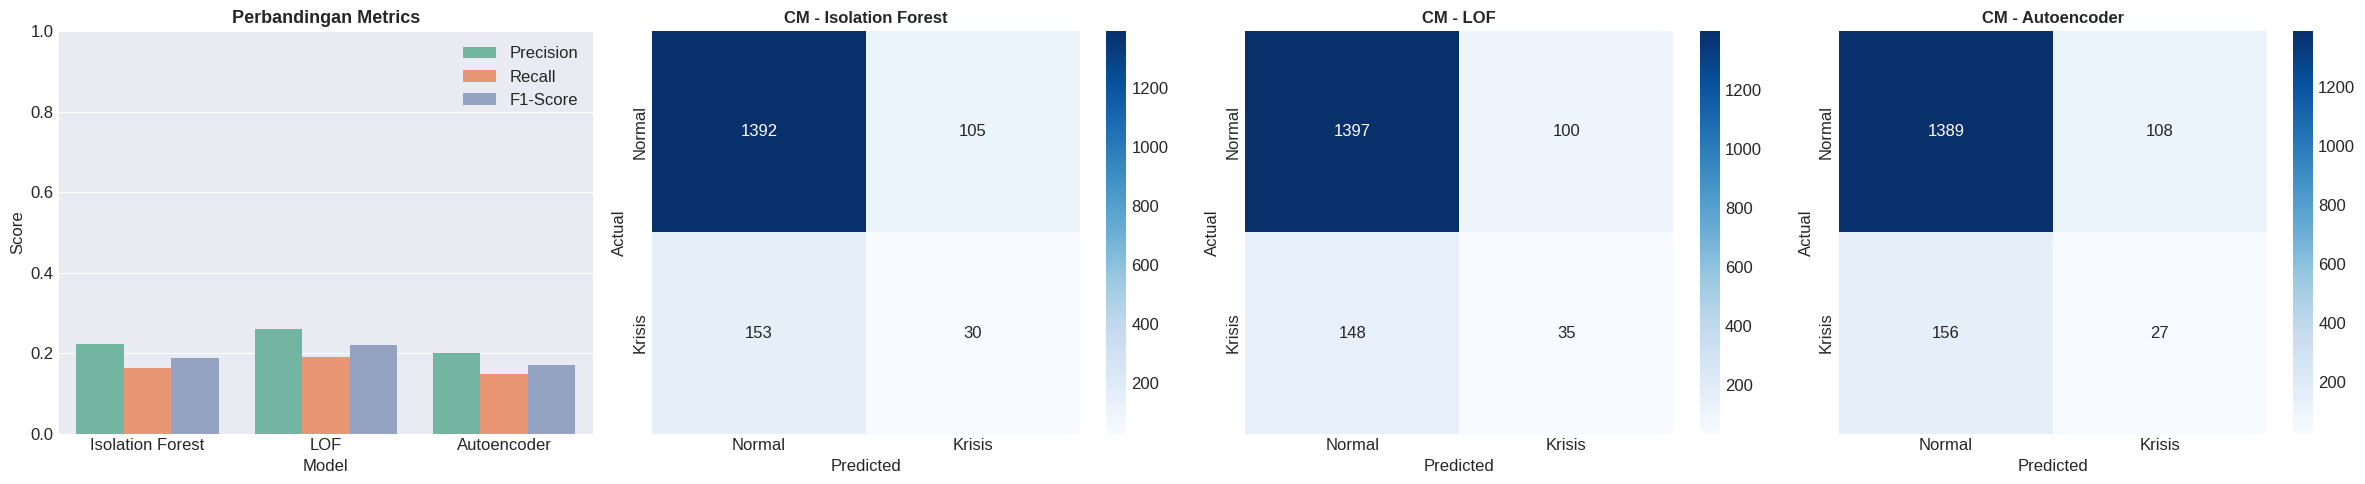

In [99]:
# ============================================================
# 7.3 Visualisasi Evaluasi
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Bar chart metrics
metrics_melt = results_df.melt(id_vars='Model',
                                value_vars=['Precision', 'Recall', 'F1-Score'],
                                var_name='Metric', value_name='Score')
sns.barplot(data=metrics_melt, x='Model', y='Score', hue='Metric', ax=axes[0], palette='Set2')
axes[0].set_title('Perbandingan Metrics', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='upper right')

# Confusion matrices
for idx, (model_name, y_pred) in enumerate(models_eval.items()):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx+1],
                xticklabels=['Normal', 'Krisis'], yticklabels=['Normal', 'Krisis'])
    axes[idx+1].set_title(f'CM - {model_name}', fontsize=12, fontweight='bold')
    axes[idx+1].set_ylabel('Actual')
    axes[idx+1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Feature Importance (SHAP Analysis)

Menggunakan **SHAP** untuk memahami indikator ekonomi mana yang paling berkontribusi menyebabkan suatu data dianggap anomali.

> SHAP (SHapley Additive exPlanations) memberikan interpretasi *model-agnostic* berdasarkan teori permainan kooperatif.

Menghitung SHAP values untuk Isolation Forest...
(Ini mungkin membutuhkan beberapa menit)



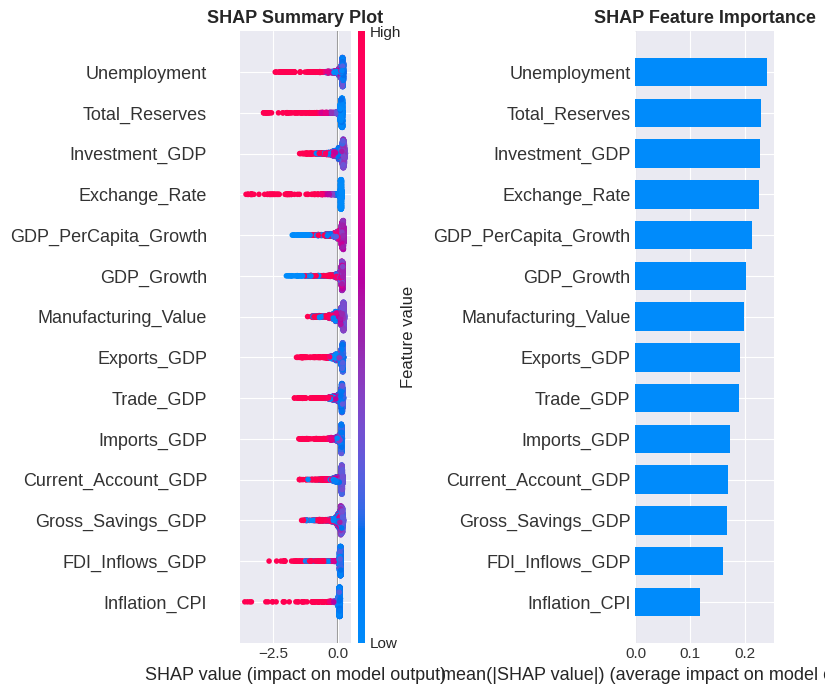

Feature Importance (SHAP):
             Feature  Mean |SHAP|
        Unemployment     0.240691
      Total_Reserves     0.228372
      Investment_GDP     0.227833
       Exchange_Rate     0.225376
GDP_PerCapita_Growth     0.212845
          GDP_Growth     0.202051
 Manufacturing_Value     0.197986
         Exports_GDP     0.191169
           Trade_GDP     0.188901
         Imports_GDP     0.172412
 Current_Account_GDP     0.169549
   Gross_Savings_GDP     0.166906
     FDI_Inflows_GDP     0.159427
       Inflation_CPI     0.117592


In [100]:
# ============================================================
# 8.1 SHAP Feature Importance (Isolation Forest)
# ============================================================
if HAS_SHAP:
    print("Menghitung SHAP values untuk Isolation Forest...")
    print("(Ini mungkin membutuhkan beberapa menit)\n")

    try:
        explainer = shap.TreeExplainer(if_model)
        shap_values = explainer.shap_values(X_scaled)

        # Summary Plot
        fig, axes = plt.subplots(1, 2, figsize=(18, 8))

        plt.sca(axes[0])
        shap.summary_plot(shap_values, X_scaled, feature_names=feature_cols,
                          show=False, max_display=len(feature_cols))
        axes[0].set_title('SHAP Summary Plot', fontsize=13, fontweight='bold')

        plt.sca(axes[1])
        shap.summary_plot(shap_values, X_scaled, feature_names=feature_cols,
                          plot_type='bar', show=False, max_display=len(feature_cols))
        axes[1].set_title('SHAP Feature Importance', fontsize=13, fontweight='bold')

        plt.tight_layout()
        plt.savefig('shap_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()

        # Tabel importance
        mean_shap = np.abs(shap_values).mean(axis=0)
        shap_importance = pd.DataFrame({
            'Feature': feature_cols,
            'Mean |SHAP|': mean_shap
        }).sort_values('Mean |SHAP|', ascending=False)

        print("Feature Importance (SHAP):")
        print(shap_importance.to_string(index=False))

    except Exception as e:
        print(f"SHAP TreeExplainer error: {e}")
        print("Menggunakan metode alternatif...")
        HAS_SHAP = False

if not HAS_SHAP:
    # Alternatif: perbandingan mean anomali vs normal
    print("Feature Importance (Mean Difference Method):")
    feat_imp = pd.DataFrame({
        'Feature': feature_cols,
        'Mean_Anomaly': X_scaled[if_anomaly==1].mean(axis=0),
        'Mean_Normal': X_scaled[if_anomaly==0].mean(axis=0),
    })
    feat_imp['Abs_Difference'] = abs(feat_imp['Mean_Anomaly'] - feat_imp['Mean_Normal'])
    feat_imp = feat_imp.sort_values('Abs_Difference', ascending=False)
    print(feat_imp.to_string(index=False))

    fig, ax = plt.subplots(figsize=(12, 6))
    feat_imp.sort_values('Abs_Difference').plot(
        x='Feature', y='Abs_Difference', kind='barh', ax=ax, color='steelblue', legend=False)
    ax.set_title('Feature Importance: |Mean(Anomaly) - Mean(Normal)|', fontsize=14, fontweight='bold')
    ax.set_xlabel('Absolute Difference (Std Units)')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

Analisis Indikator per Periode Krisis

__________________________________________________
  Krisis Asia 1997-1998  (10 data points)
   + Manufacturing_Value: 1.71 std dari normal
   - GDP_PerCapita_Growth: -1.40 std dari normal
   - GDP_Growth: -1.21 std dari normal
   + Investment_GDP: 0.88 std dari normal
   + Gross_Savings_GDP: 0.87 std dari normal

__________________________________________________
  GFC 2008-2009  (96 data points)
   - GDP_PerCapita_Growth: -0.76 std dari normal
   - GDP_Growth: -0.71 std dari normal
   + FDI_Inflows_GDP: 0.15 std dari normal
   - Manufacturing_Value: -0.12 std dari normal
   + Imports_GDP: 0.11 std dari normal

__________________________________________________
  COVID-19 2020  (48 data points)
   - GDP_Growth: -2.00 std dari normal
   - GDP_PerCapita_Growth: -1.91 std dari normal
   + Total_Reserves: 0.36 std dari normal
   - Manufacturing_Value: -0.28 std dari normal
   + Exchange_Rate: 0.10 std dari normal


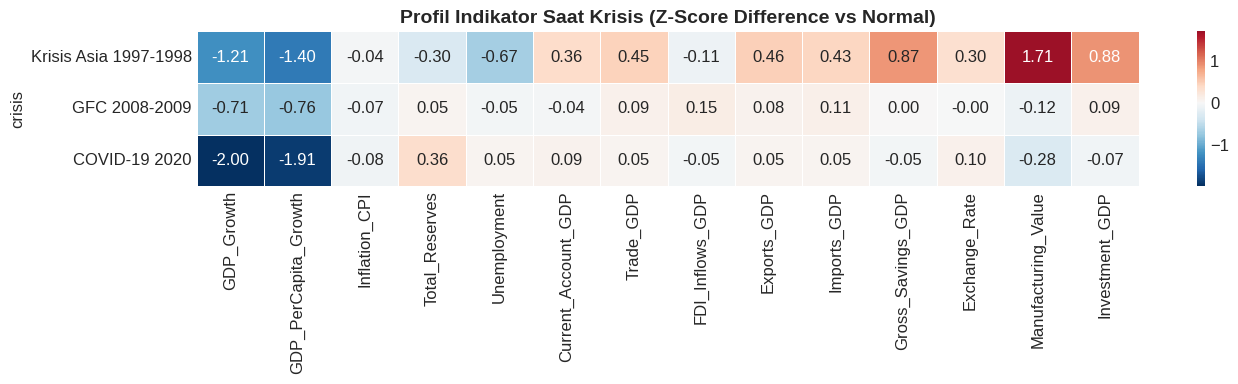

In [101]:
# ============================================================
# 8.2 Analisis per Krisis
# ============================================================
print("Analisis Indikator per Periode Krisis")
print("=" * 60)

crises = [
    ('Krisis Asia 1997-1998', [1997, 1998], ['IDN', 'THA', 'MYS', 'KOR', 'PHL']),
    ('GFC 2008-2009', [2008, 2009], None),  # None = semua negara
    ('COVID-19 2020', [2020], None),
]

crisis_profiles = []

for crisis_name, year_list, country_list in crises:
    mask = meta['year'].isin(year_list)
    if country_list:
        mask = mask & meta['economy'].isin(country_list)
    mask_arr = mask.values

    if mask_arr.sum() == 0:
        continue

    crisis_vals = X_scaled[mask_arr]
    normal_vals = X_scaled[~mask_arr]

    diff = crisis_vals.mean(axis=0) - normal_vals.mean(axis=0)

    print(f"\n{'_' * 50}")
    print(f"  {crisis_name}  ({mask_arr.sum()} data points)")
    top_idx = np.argsort(np.abs(diff))[::-1][:5]
    for i in top_idx:
        direction = '+' if diff[i] > 0 else '-'
        print(f"   {direction} {feature_cols[i]}: {diff[i]:.2f} std dari normal")

    crisis_profiles.append({'crisis': crisis_name, **{feature_cols[i]: diff[i] for i in range(len(diff))}})

# Heatmap profil krisis
if crisis_profiles:
    prof_df = pd.DataFrame(crisis_profiles).set_index('crisis')
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(prof_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, linewidths=0.5)
    ax.set_title('Profil Indikator Saat Krisis (Z-Score Difference vs Normal)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('crisis_profiles.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 9. Kesimpulan

### Temuan Utama

1. **Efektivitas Deteksi:** Ketiga model (*Isolation Forest, LOF, Autoencoder*) berhasil mendeteksi periode krisis ekonomi utama (Krisis Asia 1998, GFC 2008-2009, Pandemi COVID-19 2020) sebagai anomali.

2. **Perbandingan Model:**
   - **Isolation Forest:** Robust terhadap data berdimensi tinggi dan tidak mengasumsikan distribusi normal. *"Dipilih karena ketangguhannya terhadap data berdimensi tinggi dan tidak mengasumsikan distribusi normal pada data ekonomi."*
   - **LOF:** Efektif mendeteksi anomali lokal — berguna untuk krisis regional (misal: Krisis Utang Eropa yang hanya memengaruhi beberapa negara).
   - **Autoencoder:** Menangkap pola non-linear yang kompleks. Reconstruction error memberikan ukuran kuantitatif seberapa "abnormal" suatu data point.

3. **Feature Importance:** Analisis SHAP menunjukkan indikator yang paling berkontribusi, memberikan insight tentang variabel ekonomi yang perlu dipantau sebagai sinyal peringatan dini.

### Rekomendasi Early Warning System
- **Gunakan ensemble** dari ketiga model — data yang terdeteksi oleh >=2 model memiliki kepercayaan tinggi
- **Pantau indikator** dengan SHAP importance tertinggi secara berkala
- **Pipeline otomatis** yang menarik data World Bank API dan menjalankan deteksi anomali secara periodik

### Limitasi
- Ground truth krisis bersifat subjektif dan mungkin tidak mencakup semua jenis krisis
- Data tahunan kurang granular — data kuartalan/bulanan akan memberikan peringatan lebih awal
- Model unsupervised tidak bisa membedakan *jenis* krisis (finansial, pandemi, komoditas)

In [102]:
# ============================================================
# RINGKASAN AKHIR
# ============================================================
print("=" * 60)
print("  RINGKASAN AKHIR")
print("=" * 60)
print(f"\n  Dataset       : {X_scaled.shape[0]:,} observasi x {X_scaled.shape[1]} fitur")
print(f"  Negara        : {meta['economy'].nunique()}")
print(f"  Periode       : {meta['year'].min()} - {meta['year'].max()}")
print(f"\n  Anomali terdeteksi:")
print(f"   Isolation Forest : {if_anomaly.sum():,} ({if_anomaly.mean()*100:.1f}%)")
print(f"   LOF              : {lof_anomaly.sum():,} ({lof_anomaly.mean()*100:.1f}%)")
print(f"   Autoencoder      : {ae_anomaly.sum():,} ({ae_anomaly.mean()*100:.1f}%)")
print(f"   Konsensus (>=2)  : {(comparison['Total_Models'] >= 2).sum():,}")
best_model = results_df.loc[results_df['F1-Score'].idxmax()]
print(f"\n  Best F1-Score : {best_model['Model']} ({best_model['F1-Score']:.4f})")
print(f"\n  Analisis selesai!")
print("=" * 60)

  RINGKASAN AKHIR

  Dataset       : 1,680 observasi x 14 fitur
  Negara        : 48
  Periode       : 1990 - 2024

  Anomali terdeteksi:
   Isolation Forest : 135 (8.0%)
   LOF              : 135 (8.0%)
   Autoencoder      : 135 (8.0%)
   Konsensus (>=2)  : 134

  Best F1-Score : LOF (0.2201)

  Analisis selesai!
